# 🍎 Fruit & Vegetable Freshness Detector
### AI/ML Model with Live Camera Detection

This notebook:
- Trains a CNN model to classify fruits/vegetables as **Fresh** or **Rotten**
- Provides detailed **nutritional & storage info** for each item
- Supports **live camera detection** via OpenCV
- Uses **Transfer Learning** (MobileNetV2) for high accuracy

---
**Dataset required:** [Kaggle - Fruits Fresh and Rotten](https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification)

Or use: [Kaggle - Fresh and Rotten Classification](https://www.kaggle.com/datasets/swoyam2609/fresh-and-stale-classification)

## 📦 Step 1: Install Required Libraries

In [3]:
# Install dependencies
%pip install tensorflow opencv-python matplotlib numpy pillow seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.2 MB 14.7 MB/s eta 0:00:03
   ------ --------------------------------- 6.6/40.2 MB 25.2 MB/s eta 0:00:02
   -------- ------------------------------- 8.4/40.2 MB 16.4 MB/s eta 0:00:02
   -------------- ------------------------- 14.9/40.2 MB 20.7 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/40.2 MB 21.4 MB/s eta 0:00:02
   ------------------- -------------------- 19.9/40.2 MB 17.2 MB/s eta 0:00:02
   ------------------------ --------------- 24.4/40.2 MB 19.0 MB/s eta 0:00:01
   ------------------------------- -------- 31.7/40.2 MB 20.0 MB/s eta 0:00:01
   -------------------------------------- - 38.3/40.2 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 21.1 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 19.3 MB/

## 📚 Step 2: Import Libraries

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from IPython.display import display, clear_output
import ipywidgets as widgets

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ OpenCV Version: {cv2.__version__}")
print(f"✅ GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow Version: 2.20.0
✅ OpenCV Version: 4.13.0
✅ GPU Available: False


## 🗂️ Step 3: Dataset Setup

**Expected folder structure:**
```
dataset/
├── train/
│   ├── freshapples/
│   ├── rottenapples/
│   ├── freshbanana/
│   ├── rottenbanana/
│   ├── freshoranges/
│   ├── rottenoranges/
│   └── ... (other fruits/veggies)
└── test/
    ├── freshapples/
    ├── rottenapples/
    └── ...
```

In [16]:
# ============================================================
# CONFIGURATION — Update these paths to match your dataset
# ============================================================

TRAIN_DIR = 'C:/Users/ritik/OneDrive/Desktop/Downloads/archive/dataset/train'   # Path to training data
TEST_DIR  = 'C:/Users/ritik/OneDrive/Desktop/Downloads/archive/dataset/test'    # Path to test data
MODEL_SAVE_PATH = 'freshness_model.h5'

IMG_SIZE    = (224, 224)     # MobileNetV2 input size
BATCH_SIZE  = 32
EPOCHS      = 25
LEARNING_RATE = 0.0001

# ============================================================
# Verify dataset structure
# ============================================================
def verify_dataset(directory):
    if not os.path.exists(directory):
        print(f"❌ Directory not found: {directory}")
        return []
    classes = sorted(os.listdir(directory))
    classes = [c for c in classes if os.path.isdir(os.path.join(directory, c))]
    total_images = 0
    print(f"\n📁 Classes in '{directory}':")
    for cls in classes:
        n = len(os.listdir(os.path.join(directory, cls)))
        total_images += n
        print(f"   {'🟢' if 'fresh' in cls.lower() else '🔴'} {cls:<30} {n:>5} images")
    print(f"\n   Total: {total_images} images across {len(classes)} classes")
    return classes

train_classes = verify_dataset(TRAIN_DIR)
test_classes  = verify_dataset(TEST_DIR)


📁 Classes in 'C:/Users/ritik/OneDrive/Desktop/Downloads/archive/dataset/train':
   🟢 freshapples                     1693 images
   🟢 freshbanana                     1581 images
   🟢 freshoranges                    1466 images
   🔴 rottenapples                    2342 images
   🔴 rottenbanana                    2224 images
   🔴 rottenoranges                   1595 images

   Total: 10901 images across 6 classes

📁 Classes in 'C:/Users/ritik/OneDrive/Desktop/Downloads/archive/dataset/test':
   🟢 freshapples                      395 images
   🟢 freshbanana                      381 images
   🟢 freshoranges                     388 images
   🔴 rottenapples                     601 images
   🔴 rottenbanana                     530 images
   🔴 rottenoranges                    403 images

   Total: 2698 images across 6 classes


## 🔄 Step 4: Data Augmentation & Preprocessing

In [17]:
# Data augmentation for training to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.15   # 15% of training data used for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Save class index mapping
CLASS_INDICES = train_generator.class_indices
CLASS_NAMES = {v: k for k, v in CLASS_INDICES.items()}
NUM_CLASSES = len(CLASS_INDICES)

print(f"\n✅ Number of classes: {NUM_CLASSES}")
print(f"✅ Class mapping:")
for k, v in CLASS_NAMES.items():
    print(f"   {k}: {v}")

Found 9269 images belonging to 6 classes.
Found 1632 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.

✅ Number of classes: 6
✅ Class mapping:
   0: freshapples
   1: freshbanana
   2: freshoranges
   3: rottenapples
   4: rottenbanana
   5: rottenoranges


## 🧠 Step 5: Build the Model (Transfer Learning — MobileNetV2)

In [18]:
def build_model(num_classes, img_size=(224, 224), learning_rate=0.0001):
    """
    Build a transfer learning model using MobileNetV2 as the backbone.
    MobileNetV2 is lightweight and accurate — ideal for real-time detection.
    """
    # Load MobileNetV2 pre-trained on ImageNet, without the top classification layer
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model layers initially
    base_model.trainable = False

    # Build the full model
    inputs = keras.Input(shape=(*img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

model, base_model = build_model(NUM_CLASSES, IMG_SIZE, LEARNING_RATE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,051,846 (11.64 MB)

 Trainable params: 791,302 (3.02 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 🏋️ Step 6: Train the Model (Phase 1 — Top Layers Only)

In [19]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
print("✅ Phase 1 complete!")

🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6233 - loss: 1.0358
Epoch 1: val_accuracy improved from None to 0.95833, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 897s 3s/step - accuracy: 0.7744 - loss: 0.6176 - val_accuracy: 0.9583 - val_loss: 0.1329 - learning_rate: 1.0000e-04
Epoch 2/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9054 - loss: 0.2529
Epoch 2: val_accuracy improved from 0.95833 to 0.97733, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 701s 2s/step - accuracy: 0.9157 - loss: 0.2311 - val_accuracy: 0.9773 - val_loss: 0.0753 - learning_rate: 1.0000e-04
Epoch 3/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9429 - loss: 0.1637
Epoch 3: val_accuracy improved from 0.97733 to 0.97917, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.9450 - loss: 0.1607 - val_accuracy: 0.9792 - val_loss: 0.0560 - learning_rate: 1.0000e-04
Epoch 4/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9489 - loss: 0.1588
Epoch 4: val_accuracy improved from 0.97917 to 0.98591, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.9521 - loss: 0.1423 - val_accuracy: 0.9859 - val_loss: 0.0386 - learning_rate: 1.0000e-04
Epoch 5/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9596 - loss: 0.1213
Epoch 5: val_accuracy improved from 0.98591 to 0.99081, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.9598 - loss: 0.1174 - val_accuracy: 0.9908 - val_loss: 0.0303 - learning_rate: 1.0000e-04
Epoch 6/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9655 - loss: 0.0995
Epoch 6: val_accuracy improved from 0.99081 to 0.99265, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.9661 - loss: 0.0958 - val_accuracy: 0.9926 - val_loss: 0.0261 - learning_rate: 1.0000e-04
Epoch 7/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9643 - loss: 0.1010
Epoch 7: val_accuracy improved from 0.99265 to 0.99387, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.9663 - loss: 0.0927 - val_accuracy: 0.9939 - val_loss: 0.0216 - learning_rate: 1.0000e-04
Epoch 8/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9714 - loss: 0.0853
Epoch 8: val_accuracy improved from 0.99387 to 0.99694, saving model to freshness_model.h5


290/290 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.9696 - loss: 0.0870 - val_accuracy: 0.9969 - val_loss: 0.0159 - learning_rate: 1.0000e-04
Epoch 9/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9715 - loss: 0.0829
Epoch 9: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.9736 - loss: 0.0777 - val_accuracy: 0.9926 - val_loss: 0.0196 - learning_rate: 1.0000e-04
Epoch 10/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9707 - loss: 0.0810
Epoch 10: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.9710 - loss: 0.0786 - val_accuracy: 0.9963 - val_loss: 0.0134 - learning_rate: 1.0000e-04
Epoch 11/25
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9748 - loss: 0.0707
Epoch 11: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9768 - loss: 0.0669 - val_accuracy: 0.9933 - val_loss: 0.0194 - learning_rate: 1.0000e-04
Epoc

## 🔧 Step 7: Fine-Tune (Phase 2 — Unfreeze Top Layers of Base)

In [20]:
print("🔧 Phase 2: Fine-tuning top layers of MobileNetV2...")

# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
print("✅ Phase 2 complete! Model saved to:", MODEL_SAVE_PATH)

🔧 Phase 2: Fine-tuning top layers of MobileNetV2...
Epoch 1/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9068 - loss: 0.2611
Epoch 1: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9273 - loss: 0.2113 - val_accuracy: 0.9737 - val_loss: 0.0826 - learning_rate: 1.0000e-05
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9494 - loss: 0.1445
Epoch 2: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.9512 - loss: 0.1399 - val_accuracy: 0.9816 - val_loss: 0.0534 - learning_rate: 1.0000e-05
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9564 - loss: 0.1278
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.99694
290/290 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.9605 - loss: 0.1184 - val_accuracy: 0.9835 - val_loss: 0.0398 - learning_rate: 1.0000e-05
Epoch 4/15
290/290 ━━━━━

## 📊 Step 8: Plot Training History

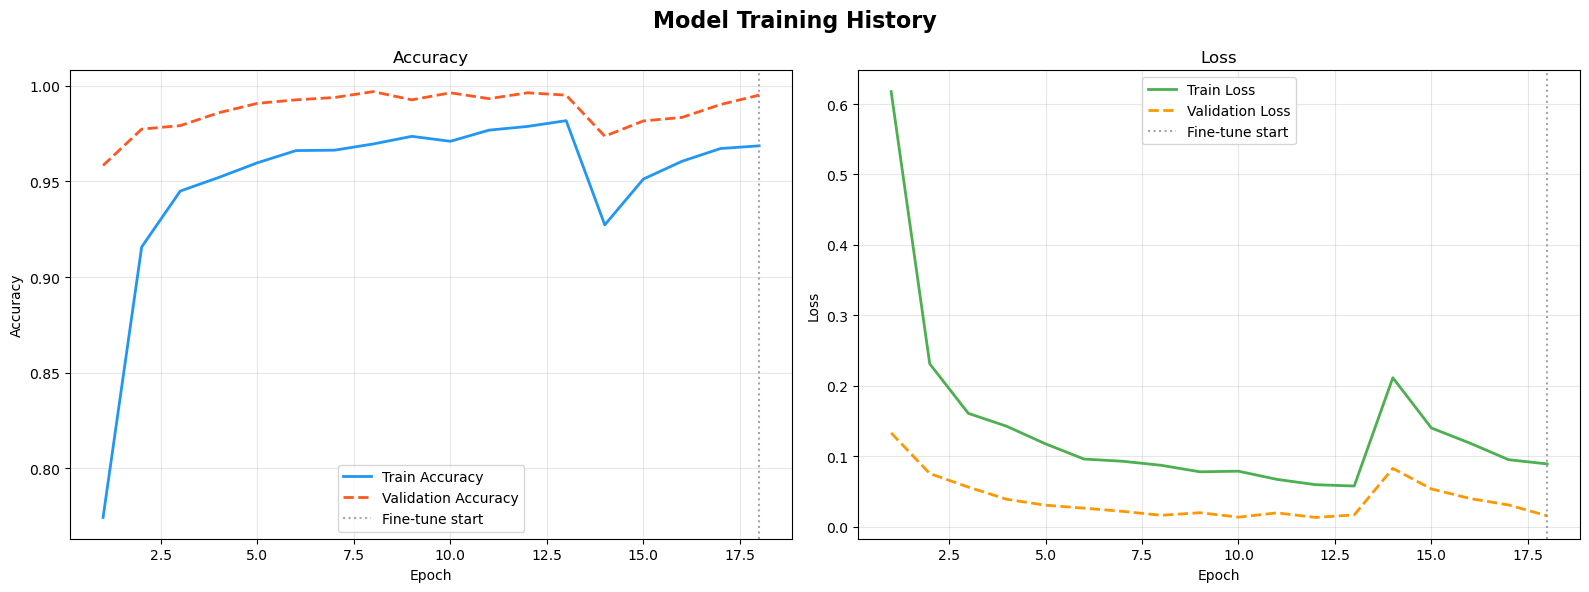

📈 Training plot saved as 'training_history.png'


In [21]:
def plot_history(h1, h2=None):
    """
    Plot accuracy and loss curves from training history.
    Merges Phase 1 and Phase 2 histories if both are provided.
    """
    acc  = h1.history['accuracy']
    val_acc  = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc      += h2.history['accuracy']
        val_acc  += h2.history['val_accuracy']
        loss     += h2.history['loss']
        val_loss += h2.history['val_loss']
        phase2_start = len(h1.history['accuracy'])
    else:
        phase2_start = None

    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs_range, acc,     label='Train Accuracy',      color='#2196F3', linewidth=2)
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy',  color='#FF5722', linewidth=2, linestyle='--')
    if phase2_start:
        axes[0].axvline(phase2_start, color='gray', linestyle=':', alpha=0.7, label='Fine-tune start')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, loss,     label='Train Loss',     color='#4CAF50', linewidth=2)
    axes[1].plot(epochs_range, val_loss, label='Validation Loss', color='#FF9800', linewidth=2, linestyle='--')
    if phase2_start:
        axes[1].axvline(phase2_start, color='gray', linestyle=':', alpha=0.7, label='Fine-tune start')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📈 Training plot saved as 'training_history.png'")

plot_history(history1, history2)

## 📈 Step 9: Evaluate on Test Set

🔍 Evaluating on test set...
85/85 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9774 - loss: 0.0581

✅ Test Accuracy : 97.74%
✅ Test Loss     : 0.0581
85/85 ━━━━━━━━━━━━━━━━━━━━ 75s 837ms/step

📋 Classification Report:
               precision    recall  f1-score   support

  freshapples       0.96      0.98      0.97       395
  freshbanana       0.97      1.00      0.98       381
 freshoranges       0.97      0.99      0.98       388
 rottenapples       0.98      0.97      0.97       601
 rottenbanana       1.00      0.96      0.98       530
rottenoranges       0.98      0.97      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



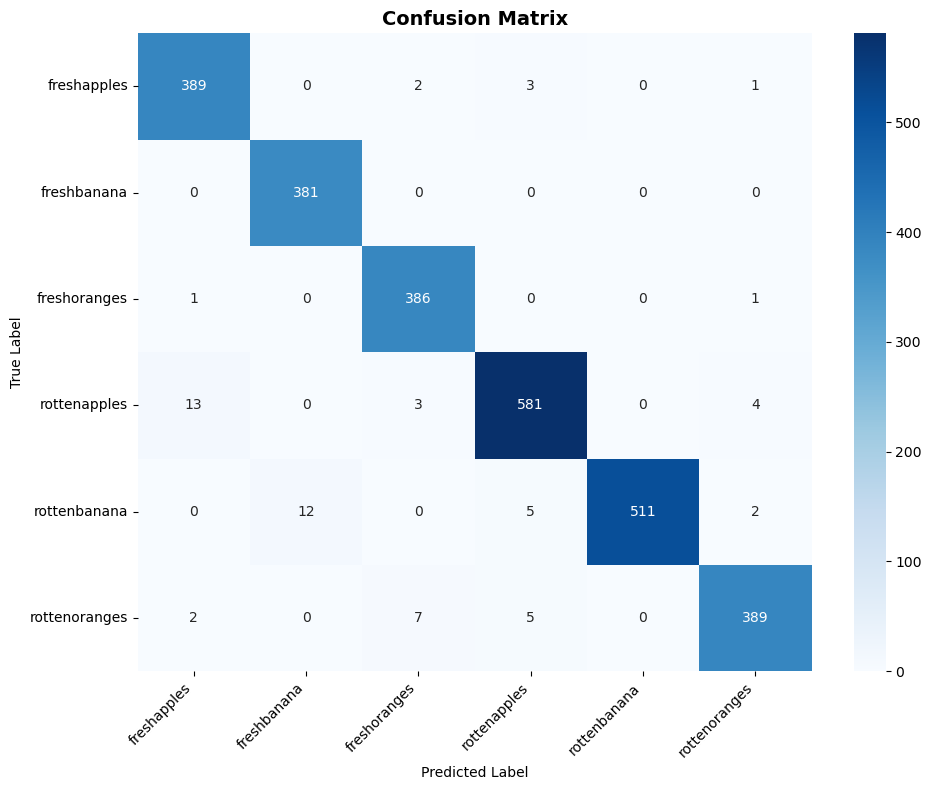

In [22]:
print("🔍 Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy : {test_accuracy*100:.2f}%")
print(f"✅ Test Loss     : {test_loss:.4f}")

# Confusion matrix
test_generator.reset()
preds = model.predict(test_generator, verbose=1)
pred_classes  = np.argmax(preds, axis=1)
true_classes  = test_generator.classes
class_labels  = list(test_generator.class_indices.keys())

print("\n📋 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Plot confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 📖 Step 10: Fruit & Vegetable Info Database

In [23]:
# =====================================================================
# COMPREHENSIVE INFO DATABASE
# Add more entries or edit existing ones as needed!
# =====================================================================

PRODUCE_INFO = {
    # ── FRUITS ──────────────────────────────────────────────────────
    'apple': {
        'emoji': '🍎',
        'type': 'Fruit',
        'nutrition': {'Calories': '95 kcal', 'Carbs': '25g', 'Fiber': '4.4g', 'Vitamin C': '14%DV', 'Potassium': '195mg'},
        'health_benefits': ['Reduces heart disease risk', 'Aids digestion', 'Supports weight management', 'Rich in antioxidants'],
        'shelf_life': {'Room temp': '1-2 weeks', 'Refrigerator': '4-6 weeks'},
        'storage_tips': 'Store in refrigerator crisper drawer. Keep away from other produce — apples emit ethylene gas that speeds ripening.',
        'fresh_signs': 'Firm, smooth, bright skin with no soft spots.',
        'rot_signs': 'Soft/mushy texture, brown spots, wrinkled skin, mold, fermented smell.'
    },
    'banana': {
        'emoji': '🍌',
        'type': 'Fruit',
        'nutrition': {'Calories': '89 kcal', 'Carbs': '23g', 'Fiber': '2.6g', 'Vitamin B6': '25%DV', 'Potassium': '422mg'},
        'health_benefits': ['Boosts energy', 'Supports heart health', 'Improves digestion', 'Reduces muscle cramps'],
        'shelf_life': {'Room temp': '2-7 days', 'Refrigerator': '7-10 days (skin darkens, fruit stays good)'},
        'storage_tips': 'Store at room temperature. Wrap stem in plastic to slow ripening. Refrigerate once ripe.',
        'fresh_signs': 'Bright yellow, slightly firm, no brown patches.',
        'rot_signs': 'Heavily blackened skin, extremely mushy texture, sour or fermented smell.'
    },
    'orange': {
        'emoji': '🍊',
        'type': 'Fruit',
        'nutrition': {'Calories': '62 kcal', 'Carbs': '15g', 'Fiber': '3.1g', 'Vitamin C': '116%DV', 'Folate': '10%DV'},
        'health_benefits': ['Immune system boost', 'Skin health', 'Reduces inflammation', 'Lowers cholesterol'],
        'shelf_life': {'Room temp': '1-2 weeks', 'Refrigerator': '3-4 weeks'},
        'storage_tips': 'Store loosely in refrigerator. Avoid sealing in airtight bags as moisture causes mold.',
        'fresh_signs': 'Firm, heavy for size, bright orange color, no soft spots.',
        'rot_signs': 'Mold patches, mushy spots, sour smell, very wrinkled skin.'
    },
    'mango': {
        'emoji': '🥭',
        'type': 'Fruit',
        'nutrition': {'Calories': '99 kcal', 'Carbs': '25g', 'Fiber': '2.6g', 'Vitamin C': '67%DV', 'Vitamin A': '10%DV'},
        'health_benefits': ['Supports immunity', 'Improves digestion', 'Eye health', 'Anti-inflammatory'],
        'shelf_life': {'Room temp': '2-3 days (ripe)', 'Refrigerator': '5-7 days (ripe)'},
        'storage_tips': 'Ripen at room temperature, then refrigerate. Frozen mango lasts 6 months.',
        'fresh_signs': 'Slightly yielding to pressure, fruity aroma, vibrant color.',
        'rot_signs': 'Very soft/mushy, black patches, fermented smell, mold growth.'
    },
    'strawberry': {
        'emoji': '🍓',
        'type': 'Fruit',
        'nutrition': {'Calories': '49 kcal', 'Carbs': '12g', 'Fiber': '3g', 'Vitamin C': '149%DV', 'Folate': '9%DV'},
        'health_benefits': ['Heart health', 'Blood sugar regulation', 'Anti-inflammatory', 'Rich in antioxidants'],
        'shelf_life': {'Room temp': '1-2 days', 'Refrigerator': '3-7 days'},
        'storage_tips': 'Do not wash until ready to eat. Store in single layers in refrigerator with paper towel.',
        'fresh_signs': 'Bright red, firm, intact hull, fresh fruity smell.',
        'rot_signs': 'Mold (white/gray fuzzy growth), mushy texture, dull color, sour smell.'
    },
    'grapes': {
        'emoji': '🍇',
        'type': 'Fruit',
        'nutrition': {'Calories': '69 kcal', 'Carbs': '18g', 'Fiber': '0.9g', 'Vitamin K': '22%DV', 'Vitamin C': '6%DV'},
        'health_benefits': ['Antioxidant-rich', 'Heart health', 'Anti-inflammatory', 'Supports brain health'],
        'shelf_life': {'Room temp': '1-2 days', 'Refrigerator': '1-2 weeks'},
        'storage_tips': 'Store unwashed in perforated bag in refrigerator. Wash just before eating.',
        'fresh_signs': 'Plump, firm, attached to stem, bloom (white powder) intact.',
        'rot_signs': 'Shriveled, leaking juice, brown spots, mold, off smell.'
    },
    'pomegranate': {
        'emoji': '🍎',
        'type': 'Fruit',
        'nutrition': {'Calories': '83 kcal', 'Carbs': '19g', 'Fiber': '4g', 'Vitamin C': '17%DV', 'Vitamin K': '16%DV'},
        'health_benefits': ['Powerful antioxidants', 'Reduces blood pressure', 'Anti-inflammatory', 'Memory improvement'],
        'shelf_life': {'Room temp': '1-2 weeks', 'Refrigerator': '1-2 months'},
        'storage_tips': 'Whole pomegranates last months in cool/dry conditions. Refrigerate once cut.',
        'fresh_signs': 'Heavy for size, deep red/purple color, firm and leathery skin.',
        'rot_signs': 'Lightweight, soft/sunken spots, mold at crown, sour fermented smell.'
    },

    # ── VEGETABLES ──────────────────────────────────────────────────
    'tomato': {
        'emoji': '🍅',
        'type': 'Vegetable (technically a fruit)',
        'nutrition': {'Calories': '18 kcal', 'Carbs': '3.9g', 'Fiber': '1.2g', 'Vitamin C': '28%DV', 'Lycopene': 'High'},
        'health_benefits': ['Reduces cancer risk (lycopene)', 'Heart health', 'Skin health', 'Bone health'],
        'shelf_life': {'Room temp': '3-5 days (ripe)', 'Refrigerator': '1-2 weeks (ripe)'},
        'storage_tips': 'Ripen at room temperature stem-side down. Refrigerate only once fully ripe.',
        'fresh_signs': 'Vibrant red, slightly yielding to pressure, fresh earthy smell.',
        'rot_signs': 'Very mushy, leaking juice, mold, extremely wrinkled, sour smell.'
    },
    'potato': {
        'emoji': '🥔',
        'type': 'Vegetable',
        'nutrition': {'Calories': '77 kcal', 'Carbs': '17g', 'Fiber': '2.2g', 'Vitamin C': '30%DV', 'Potassium': '620mg'},
        'health_benefits': ['Energy source', 'Blood pressure control', 'Digestive health', 'Immunity boost'],
        'shelf_life': {'Cool dark place': '3-5 weeks', 'Refrigerator': 'Not recommended — turns sweet'},
        'storage_tips': 'Store in cool, dark, ventilated space. Keep away from onions. Do NOT refrigerate raw.',
        'fresh_signs': 'Firm, smooth skin, no sprouts, no green tinge.',
        'rot_signs': 'Soft/wrinkled, foul smell, extensive green patches, large sprouts, mold.'
    },
    'carrot': {
        'emoji': '🥕',
        'type': 'Vegetable',
        'nutrition': {'Calories': '41 kcal', 'Carbs': '10g', 'Fiber': '2.8g', 'Vitamin A': '334%DV', 'Vitamin K': '13%DV'},
        'health_benefits': ['Eye health', 'Cancer prevention', 'Blood sugar control', 'Immune support'],
        'shelf_life': {'Refrigerator': '3-4 weeks', 'Freezer': '10-12 months (blanched)'},
        'storage_tips': 'Remove tops, wrap in damp paper towel, store in refrigerator crisper drawer.',
        'fresh_signs': 'Bright orange, firm, crunchy, smooth skin.',
        'rot_signs': 'Limp/rubbery, white fuzzy mold, slimy texture, foul smell.'
    },
    'bellpepper': {
        'emoji': '🫑',
        'type': 'Vegetable',
        'nutrition': {'Calories': '31 kcal', 'Carbs': '6g', 'Fiber': '2.1g', 'Vitamin C': '169%DV', 'Vitamin B6': '20%DV'},
        'health_benefits': ['Immune support', 'Eye health', 'Iron absorption', 'Anti-inflammatory'],
        'shelf_life': {'Room temp': '1-2 days', 'Refrigerator': '1-2 weeks'},
        'storage_tips': 'Store whole in refrigerator crisper. Once cut, refrigerate in airtight container — use within 3 days.',
        'fresh_signs': 'Firm, glossy, vibrant color, intact stem.',
        'rot_signs': 'Soft/wrinkled, dark sunken spots, mold, slimy inside.'
    },
    'cucumber': {
        'emoji': '🥒',
        'type': 'Vegetable',
        'nutrition': {'Calories': '16 kcal', 'Carbs': '3.6g', 'Fiber': '0.5g', 'Vitamin K': '16%DV', 'Water': '96%'},
        'health_benefits': ['Hydration', 'Weight management', 'Bone health', 'Anti-inflammatory'],
        'shelf_life': {'Room temp': '1-2 days', 'Refrigerator': '7-10 days'},
        'storage_tips': 'Wrap in paper towel and store in refrigerator. Sensitive to cold — keep above 50°F.',
        'fresh_signs': 'Dark green, firm, smooth skin, no soft ends.',
        'rot_signs': 'Soft/mushy ends, yellow patches, sliminess, mold, bitter smell.'
    },
    'spinach': {
        'emoji': '🥬',
        'type': 'Vegetable',
        'nutrition': {'Calories': '23 kcal', 'Carbs': '3.6g', 'Fiber': '2.2g', 'Iron': '15%DV', 'Vitamin K': '460%DV'},
        'health_benefits': ['Bone health', 'Blood pressure control', 'Cancer prevention', 'Eye health'],
        'shelf_life': {'Refrigerator': '5-7 days'},
        'storage_tips': 'Store in refrigerator in slightly damp paper towel in airtight container or bag.',
        'fresh_signs': 'Bright green, crisp leaves, no yellowing.',
        'rot_signs': 'Yellowed, slimy, musty smell, dark wilted leaves.'
    },
}

def get_produce_name(class_name):
    """
    Extract produce name from a class label like 'freshapples' → 'apple'
    Handles common naming patterns in freshness datasets.
    """
    name = class_name.lower()
    for prefix in ['fresh', 'rotten', 'stale', 'spoiled', 'bad', 'good']:
        name = name.replace(prefix, '')
    name = name.strip('_- ')
    # Normalize plural/alternate names
    aliases = {
        'apples': 'apple', 'bananas': 'banana', 'oranges': 'orange',
        'mangoes': 'mango', 'mangos': 'mango', 'strawberries': 'strawberry',
        'tomatoes': 'tomato', 'potatoes': 'potato', 'carrots': 'carrot',
        'peppers': 'bellpepper', 'bell_pepper': 'bellpepper', 'bellpeppers': 'bellpepper',
        'cucumbers': 'cucumber', 'grapes': 'grapes',
    }
    return aliases.get(name, name)

def is_fresh(class_name):
    """Return True if the class name indicates freshness."""
    return 'fresh' in class_name.lower() or 'good' in class_name.lower()

print("✅ Produce info database loaded with", len(PRODUCE_INFO), "entries.")

✅ Produce info database loaded with 13 entries.


## 🔍 Step 11: Single Image Prediction Function

In [24]:
def predict_image(image_path_or_array, model, class_names, img_size=(224, 224), show_plot=True):
    """
    Predict freshness of a fruit/vegetable from an image path or numpy array.
    Returns prediction dict and optionally displays a detailed info panel.
    """
    # Load image
    if isinstance(image_path_or_array, str):
        img = Image.open(image_path_or_array).convert('RGB')
        orig_img = np.array(img)
    elif isinstance(image_path_or_array, np.ndarray):
        if image_path_or_array.shape[-1] == 3:
            orig_img = image_path_or_array
        else:
            orig_img = cv2.cvtColor(image_path_or_array, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(orig_img)
    else:
        raise ValueError("Input must be a file path or numpy array.")

    # Preprocess
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_batch, verbose=0)[0]
    top_idx = np.argmax(predictions)
    confidence = predictions[top_idx] * 100
    class_name = class_names[top_idx]

    # Parse result
    fresh = is_fresh(class_name)
    produce = get_produce_name(class_name)
    info = PRODUCE_INFO.get(produce, None)

    result = {
        'class': class_name,
        'produce': produce,
        'is_fresh': fresh,
        'confidence': confidence,
        'all_predictions': {class_names[i]: predictions[i]*100 for i in range(len(predictions))}
    }

    if show_plot:
        freshness_color = '#2ECC71' if fresh else '#E74C3C'
        freshness_label = '✅ FRESH' if fresh else '❌ ROTTEN/SPOILED'
        emoji = info['emoji'] if info else '🌿'

        fig = plt.figure(figsize=(18, 10))
        fig.patch.set_facecolor('#1a1a2e')

        # ── Image ──────────────────────────────────────────────────
        ax_img = fig.add_axes([0.02, 0.05, 0.35, 0.9])
        ax_img.imshow(orig_img)
        ax_img.axis('off')
        border_color = freshness_color
        for spine in ax_img.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        ax_img.set_title(
            f"{emoji} {produce.upper()}  —  {freshness_label}",
            color='white', fontsize=13, fontweight='bold', pad=10
        )
        conf_text = f"Confidence: {confidence:.1f}%"
        ax_img.text(0.5, -0.02, conf_text, transform=ax_img.transAxes,
                    ha='center', color='#AAAAAA', fontsize=11)

        # ── Top predictions bar chart ───────────────────────────────
        ax_bar = fig.add_axes([0.41, 0.55, 0.25, 0.38])
        ax_bar.set_facecolor('#16213e')
        top5 = sorted(result['all_predictions'].items(), key=lambda x: x[1], reverse=True)[:5]
        names_top = [t[0] for t in top5]
        vals_top  = [t[1] for t in top5]
        colors = ['#2ECC71' if is_fresh(n) else '#E74C3C' for n in names_top]
        bars = ax_bar.barh(range(len(names_top)), vals_top, color=colors, alpha=0.85)
        ax_bar.set_yticks(range(len(names_top)))
        ax_bar.set_yticklabels(names_top, color='white', fontsize=9)
        ax_bar.set_xlabel('Confidence (%)', color='white', fontsize=9)
        ax_bar.set_title('Top Predictions', color='white', fontsize=10, fontweight='bold')
        ax_bar.tick_params(colors='white')
        ax_bar.spines['bottom'].set_color('gray')
        ax_bar.spines['left'].set_color('gray')
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        for bar, val in zip(bars, vals_top):
            ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{val:.1f}%', va='center', color='white', fontsize=8)

        # ── Info panel ─────────────────────────────────────────────
        ax_info = fig.add_axes([0.70, 0.05, 0.28, 0.9])
        ax_info.set_facecolor('#16213e')
        ax_info.axis('off')

        y = 0.97
        def write(text, color='white', fontsize=10, bold=False, dy=0.05):
            nonlocal y
            ax_info.text(0.05, y, text, transform=ax_info.transAxes,
                         color=color, fontsize=fontsize,
                         fontweight='bold' if bold else 'normal', va='top',
                         wrap=True)
            y -= dy

        write(f"{emoji} {produce.title()} Information", '#F1C40F', fontsize=12, bold=True, dy=0.07)

        if info:
            write(f"Type: {info['type']}", '#7FB3D3', bold=True)
            y -= 0.01

            write("📊 Nutrition (per 100g):", '#F39C12', bold=True, dy=0.06)
            for k, v in info['nutrition'].items():
                write(f"  • {k}: {v}", '#BDC3C7', fontsize=9, dy=0.04)
            y -= 0.01

            write("💪 Health Benefits:", '#27AE60', bold=True, dy=0.06)
            for b in info['health_benefits'][:3]:
                write(f"  • {b}", '#BDC3C7', fontsize=9, dy=0.04)
            y -= 0.01

            write("⏳ Shelf Life:", '#8E44AD', bold=True, dy=0.06)
            for loc, dur in info['shelf_life'].items():
                write(f"  • {loc}: {dur}", '#BDC3C7', fontsize=9, dy=0.04)
            y -= 0.01

            write("💾 Storage:", '#2980B9', bold=True, dy=0.06)
            write(f"  {info['storage_tips']}", '#BDC3C7', fontsize=8, dy=0.06)
            y -= 0.01

            status_key = 'fresh_signs' if fresh else 'rot_signs'
            status_label = '✅ Fresh Signs:' if fresh else '⚠️ Spoilage Signs:'
            status_color = '#2ECC71' if fresh else '#E74C3C'
            write(status_label, status_color, bold=True, dy=0.06)
            write(f"  {info[status_key]}", '#BDC3C7', fontsize=8, dy=0.06)
        else:
            write("ℹ️ No detailed info available for this item.", '#7F8C8D', fontsize=9)
            write("Add it to the PRODUCE_INFO dictionary!", '#7F8C8D', fontsize=9)

        # Freshness badge
        badge_y = 0.03
        badge = patches.FancyBboxPatch((0.03, badge_y), 0.94, 0.08,
            boxstyle='round,pad=0.01', linewidth=2,
            edgecolor=freshness_color, facecolor=freshness_color + '33',
            transform=ax_info.transAxes)
        ax_info.add_patch(badge)
        ax_info.text(0.5, badge_y + 0.04, freshness_label,
                     transform=ax_info.transAxes, ha='center', va='center',
                     color=freshness_color, fontsize=12, fontweight='bold')

        plt.suptitle('🌿 FreshScan — AI Freshness Detector', color='white',
                     fontsize=14, fontweight='bold', y=0.99)
        plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight',
                    facecolor='#1a1a2e')
        plt.show()

    return result

print("✅ Prediction function ready.")

✅ Prediction function ready.


## 🖼️ Step 12: Test on a Single Image

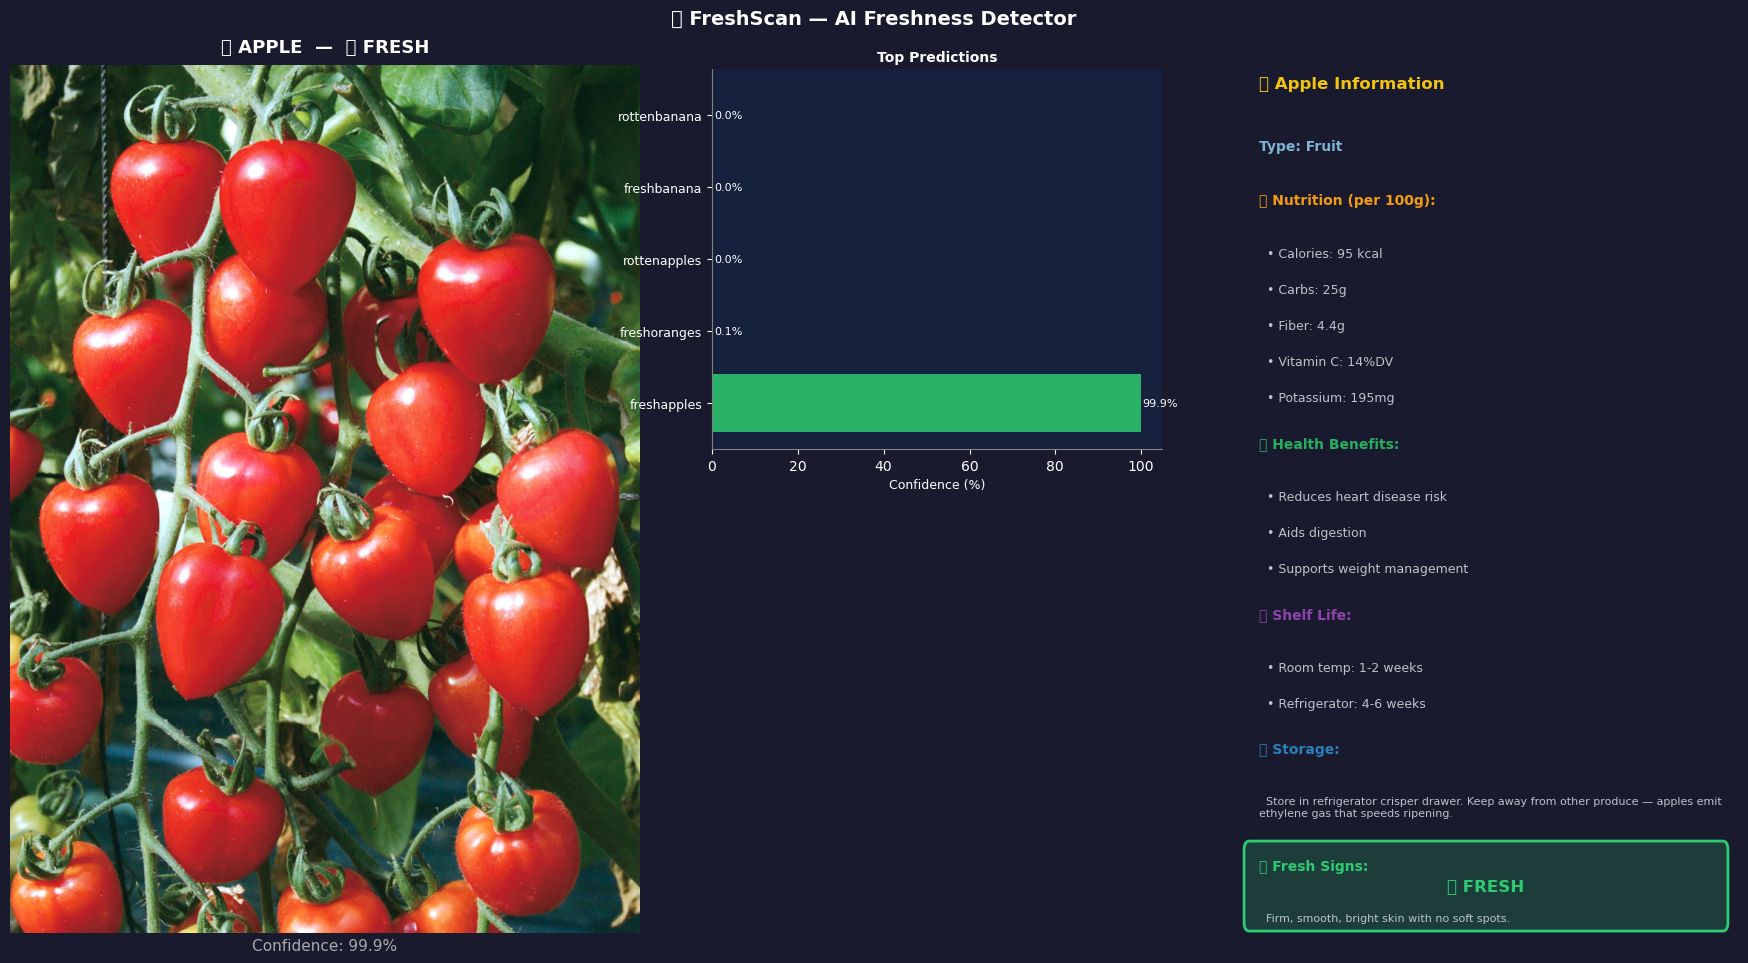


📋 Prediction Summary:
   Produce    : Apple
   Status     : ✅ Fresh
   Class      : freshapples
   Confidence : 99.85%


In [27]:
# =====================================================================
# Test with a single image — change the path to your test image!
# =====================================================================

TEST_IMAGE_PATH = 'C:/Users/ritik/OneDrive/Desktop/Downloads/second model/Fruits_Vegetables_Dataset(12000)/Vegetables/FreshTomato/freshTomato (97).jpg'
# Or: TEST_IMAGE_PATH = 'your_image.jpg'

if os.path.exists(TEST_IMAGE_PATH):
    result = predict_image(TEST_IMAGE_PATH, model, CLASS_NAMES, IMG_SIZE)
    print(f"\n📋 Prediction Summary:")
    print(f"   Produce    : {result['produce'].title()}")
    print(f"   Status     : {'✅ Fresh' if result['is_fresh'] else '❌ Rotten/Spoiled'}")
    print(f"   Class      : {result['class']}")
    print(f"   Confidence : {result['confidence']:.2f}%")
else:
    print(f"⚠️  Test image not found at: {TEST_IMAGE_PATH}")
    print("   Update TEST_IMAGE_PATH to a valid image file.")

## 🎥 Step 13: Live Camera Detection

> ⚠️ **Note:** This cell uses OpenCV to open a live camera window.
> - Press **`q`** to quit the camera.
> - Press **`s`** to save the current frame.
> - Works in **local Jupyter** (not Google Colab).
> - For Colab, use the `webcam_colab()` function in the next cell.

In [30]:
def run_live_camera(model, class_names, img_size=(224, 224), camera_index=0):
    """
    Run real-time fruit/vegetable freshness detection on live camera feed.
    
    Controls:
        q - Quit
        s - Save screenshot with prediction
        p - Pause/unpause detection
    """
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("❌ Error: Cannot open camera. Try changing camera_index (0, 1, 2).")
        return

    # Detection settings
    DETECT_INTERVAL = 15   # Run model every N frames (for performance)
    BOX_PADDING     = 30   # Padding around detection area

    frame_count = 0
    current_label = "Detecting..."
    current_conf  = 0.0
    current_fresh = None
    current_info  = None
    paused = False
    screenshot_count = 0

    # Colors (BGR)
    COLOR_FRESH  = (50, 205,  50)
    COLOR_ROTTEN = (50,  50, 220)
    COLOR_UI     = (40,  40,  40)
    COLOR_WHITE  = (255, 255, 255)
    COLOR_YELLOW = (0, 220, 220)

    print("🎥 Camera opened. Controls:  q=Quit  s=Screenshot  p=Pause")
    print("   Point your camera at a fruit or vegetable!")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Failed to grab frame.")
            break

        h, w = frame.shape[:2]
        frame_count += 1

        # ── Run prediction every DETECT_INTERVAL frames ────────────
        if not paused and frame_count % DETECT_INTERVAL == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(rgb).resize(img_size)
            img_arr = np.expand_dims(np.array(img_pil) / 255.0, axis=0)
            preds = model.predict(img_arr, verbose=0)[0]
            top_idx = np.argmax(preds)
            current_conf  = preds[top_idx] * 100
            class_name    = class_names[top_idx]
            current_fresh = is_fresh(class_name)
            produce       = get_produce_name(class_name)
            current_info  = PRODUCE_INFO.get(produce, None)
            status_str    = 'FRESH' if current_fresh else 'ROTTEN'
            current_label = f"{produce.upper()} — {status_str}"

        # ── Choose display color ───────────────────────────────────
        color = COLOR_FRESH if current_fresh else COLOR_ROTTEN
        if current_fresh is None:
            color = (180, 180, 180)

        # ── Draw detection box ─────────────────────────────────────
        cx, cy = w // 2, h // 2
        box_size = min(w, h) // 2
        x1, y1 = cx - box_size // 2, cy - box_size // 2
        x2, y2 = cx + box_size // 2, cy + box_size // 2
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Corner accents
        cl = 20  # corner length
        cv2.line(frame, (x1, y1), (x1 + cl, y1), color, 4)
        cv2.line(frame, (x1, y1), (x1, y1 + cl), color, 4)
        cv2.line(frame, (x2, y1), (x2 - cl, y1), color, 4)
        cv2.line(frame, (x2, y1), (x2, y1 + cl), color, 4)
        cv2.line(frame, (x1, y2), (x1 + cl, y2), color, 4)
        cv2.line(frame, (x1, y2), (x1, y2 - cl), color, 4)
        cv2.line(frame, (x2, y2), (x2 - cl, y2), color, 4)
        cv2.line(frame, (x2, y2), (x2, y2 - cl), color, 4)

        # ── Top status bar ─────────────────────────────────────────
        cv2.rectangle(frame, (0, 0), (w, 55), COLOR_UI, -1)
        cv2.putText(frame, current_label, (15, 35),
                    cv2.FONT_HERSHEY_DUPLEX, 0.85, color, 2)
        if current_conf > 0:
            conf_txt = f"{current_conf:.1f}% confidence"
            cv2.putText(frame, conf_txt, (w - 220, 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLOR_YELLOW, 1)

        # ── Bottom info panel ──────────────────────────────────────
        panel_h = 120
        cv2.rectangle(frame, (0, h - panel_h), (w, h), COLOR_UI, -1)

        if current_info:
            nutrition_str = "  |  ".join([f"{k}: {v}" for k, v in
                                          list(current_info['nutrition'].items())[:3]])
            shelf_str = next(iter(current_info['shelf_life'].items()))
            shelf_str = f"Shelf: {shelf_str[0]} — {shelf_str[1]}"

            cv2.putText(frame, f"Nutrition — {nutrition_str}",
                        (10, h - panel_h + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_WHITE, 1)
            cv2.putText(frame, shelf_str,
                        (10, h - panel_h + 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_YELLOW, 1)
            sign_key = 'fresh_signs' if current_fresh else 'rot_signs'
            sign_label = 'Fresh indicators' if current_fresh else '⚠ Spoilage signs'
            sign_text = f"{sign_label}: {current_info[sign_key][:80]}..."
            cv2.putText(frame, sign_text,
                        (10, h - panel_h + 75), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
            tip = f"Tip: {current_info['storage_tips'][:90]}..."
            cv2.putText(frame, tip,
                        (10, h - panel_h + 100), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (180, 180, 180), 1)

        # Pause indicator
        if paused:
            cv2.putText(frame, "⏸ PAUSED — Press p to resume",
                        (w // 2 - 160, h // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.8, COLOR_YELLOW, 2)

        # Controls hint
        cv2.putText(frame, "q:Quit  s:Screenshot  p:Pause",
                    (w - 280, h - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (130, 130, 130), 1)

        # ── Display frame ──────────────────────────────────────────
        cv2.imshow('🌿 FreshScan — Live Detection', frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            print("👋 Camera closed.")
            break
        elif key == ord('s'):
            fname = f'screenshot_{screenshot_count:03d}.jpg'
            cv2.imwrite(fname, frame)
            screenshot_count += 1
            print(f"📸 Screenshot saved: {fname}")
        elif key == ord('p'):
            paused = not paused
            print(f"{'⏸ Paused' if paused else '▶ Resumed'}")

    cap.release()
    cv2.destroyAllWindows()

# =====================================================================
# ▶️  Start the live camera!
# =====================================================================
run_live_camera(model, CLASS_NAMES, IMG_SIZE, camera_index=0)



🎥 Camera opened. Controls:  q=Quit  s=Screenshot  p=Pause
   Point your camera at a fruit or vegetable!
👋 Camera closed.


## 📷 Step 14: Google Colab Webcam Detection (Alternative)

> Use this cell **only if you are running on Google Colab** — it captures a single frame from your browser webcam.

In [ ]:
# ── Google Colab Webcam Capture ──────────────────────────────────────
# Uncomment and run this cell only in Google Colab.

# from IPython.display import display, Javascript
# from google.colab.output import eval_js
# from base64 import b64decode
# import io

# def take_photo(quality=0.8):
#     js = Javascript('''
#         async function takePhoto(quality) {
#             const div = document.createElement('div');
#             const capture = document.createElement('button');
#             capture.textContent = '📸 Capture Photo';
#             div.appendChild(capture);
#             const video = document.createElement('video');
#             video.style.display = 'block';
#             const stream = await navigator.mediaDevices.getUserMedia({video: true});
#             document.body.appendChild(div);
#             div.appendChild(video);
#             video.srcObject = stream;
#             await video.play();
#             google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
#             await new Promise((resolve) => capture.onclick = resolve);
#             const canvas = document.createElement('canvas');
#             canvas.width = video.videoWidth;
#             canvas.height = video.videoHeight;
#             canvas.getContext('2d').drawImage(video, 0, 0);
#             stream.getVideoTracks()[0].stop();
#             div.remove();
#             return canvas.toDataURL('image/jpeg', quality);
#         }
#     ''')
#     display(js)
#     data = eval_js('takePhoto({})'.format(quality))
#     binary = b64decode(data.split(',')[1])
#     img = Image.open(io.BytesIO(binary)).convert('RGB')
#     return np.array(img)

# img_array = take_photo()
# result = predict_image(img_array, model, CLASS_NAMES, IMG_SIZE)
# print(f"Result: {result['class']} — {result['confidence']:.2f}% confident")

print("ℹ️  Colab webcam code is commented out. Uncomment to use in Google Colab.")

## 💾 Step 15: Save & Load Model

In [31]:
import json

# Save model and class names
model.save(MODEL_SAVE_PATH)

with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

print(f"✅ Model saved to: {MODEL_SAVE_PATH}")
print(f"✅ Class names saved to: class_names.json")

# ── How to reload later ──────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
To reload the model in a fresh session:

  import json, tensorflow as tf
  model = tf.keras.models.load_model('freshness_model.h5')
  with open('class_names.json') as f:
      CLASS_NAMES = {int(k): v for k, v in json.load(f).items()}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✅ Model saved to: freshness_model.h5
✅ Class names saved to: class_names.json

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
To reload the model in a fresh session:

  import json, tensorflow as tf
  model = tf.keras.models.load_model('freshness_model.h5')
  with open('class_names.json') as f:
      CLASS_NAMES = {int(k): v for k, v in json.load(f).items()}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



## 🎯 Step 16: Quick Start — Load Saved Model & Detect

Use this cell to skip training and go straight to detection after you've trained once.

✅ Model loaded.
✅ 6 classes loaded.


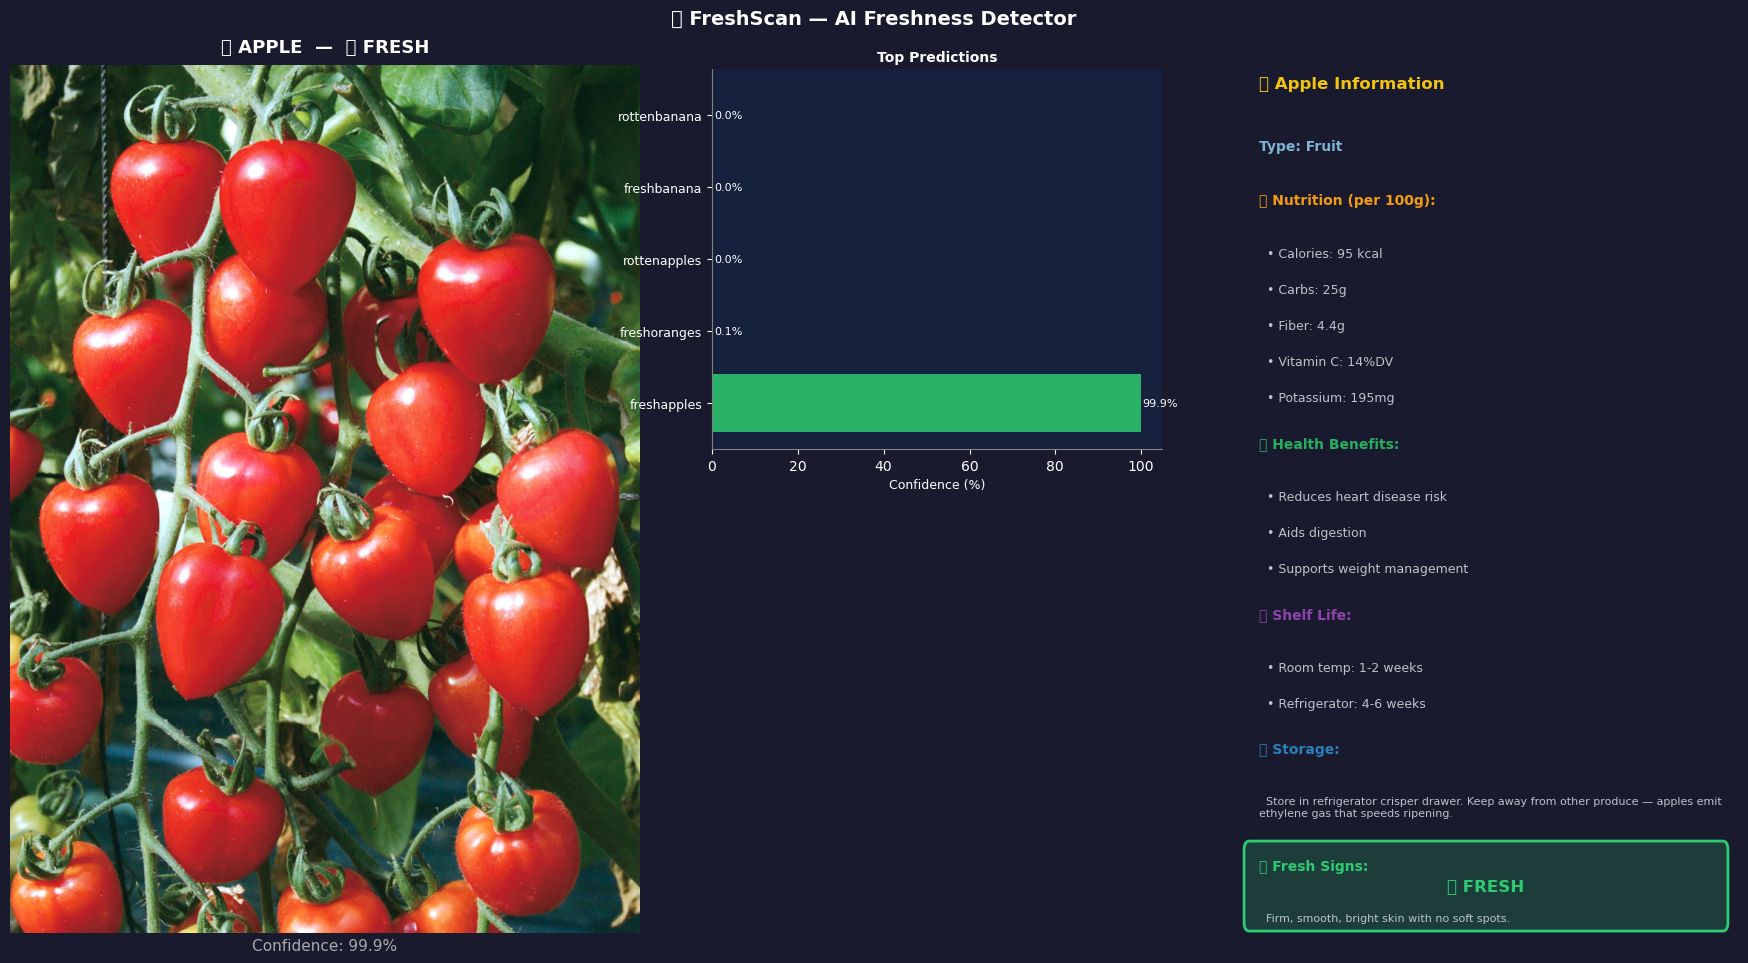


✅ Ready! Uncomment lines above to predict an image or start the camera.


In [35]:
import json
import tensorflow as tf

# Load model
model = tf.keras.models.load_model('freshness_model.h5')
print("✅ Model loaded.")

# Load class names
with open('class_names.json') as f:
    CLASS_NAMES = {int(k): v for k, v in json.load(f).items()}
print(f"✅ {len(CLASS_NAMES)} classes loaded.")

IMG_SIZE = (224, 224)

# Predict a single image
result = predict_image('C:/Users/ritik/OneDrive/Desktop/Downloads/second model/Fruits_Vegetables_Dataset(12000)/Vegetables/FreshTomato/freshTomato (97).jpg'
, model, CLASS_NAMES, IMG_SIZE)

# Start live camera
# run_live_camera(model, CLASS_NAMES, IMG_SIZE)

print("\n✅ Ready! Uncomment lines above to predict an image or start the camera.")

---
## 📚 Summary

| Feature | Details |
|---|---|
| **Model** | MobileNetV2 (Transfer Learning) |
| **Input size** | 224×224 RGB |
| **Classes** | Fresh/Rotten for each produce type |
| **Training** | 2-phase: frozen base → fine-tuning |
| **Augmentation** | Rotation, flip, zoom, brightness, shear |
| **Live detection** | OpenCV (local) / JS webcam (Colab) |
| **Info database** | 13 fruits & vegetables with nutrition, storage, shelf life |
| **Controls** | q=Quit, s=Screenshot, p=Pause |

### 📦 Recommended Dataset
- **[Fruits Fresh and Rotten — Kaggle](https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification)**
  - 13,599 images, 6 classes (fresh/rotten × apple/banana/orange)
- **[Fresh and Stale Classification — Kaggle](https://www.kaggle.com/datasets/swoyam2609/fresh-and-stale-classification)**
  - Larger dataset with more produce types

### 🚀 Tips for Better Accuracy
1. Use a **larger dataset** with more produce varieties
2. Add more **augmentation** for real-world conditions (blur, noise)
3. Try **EfficientNetB3** for higher accuracy at slightly more cost
4. Use a **YOLOv8** detector layer for multi-object detection in one frame

In [36]:
os.path.abspath('freshness_model.h5')

'C:\\Users\\ritik\\Desktop\\Downloads\\freshness_model.h5'